Variable Transformer

In [3]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [6]:
df = pd.read_csv('titanic.csv', usecols = ['Age','Fare','Survived'])

In [7]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [8]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_10610/694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [9]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

/tmp/ipykernel_10610/2888751792.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


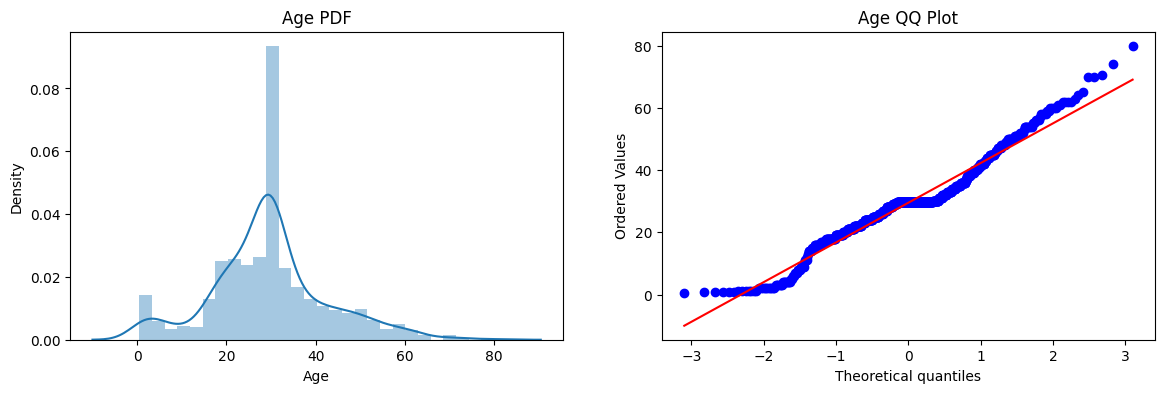

In [11]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

/tmp/ipykernel_10610/474975069.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


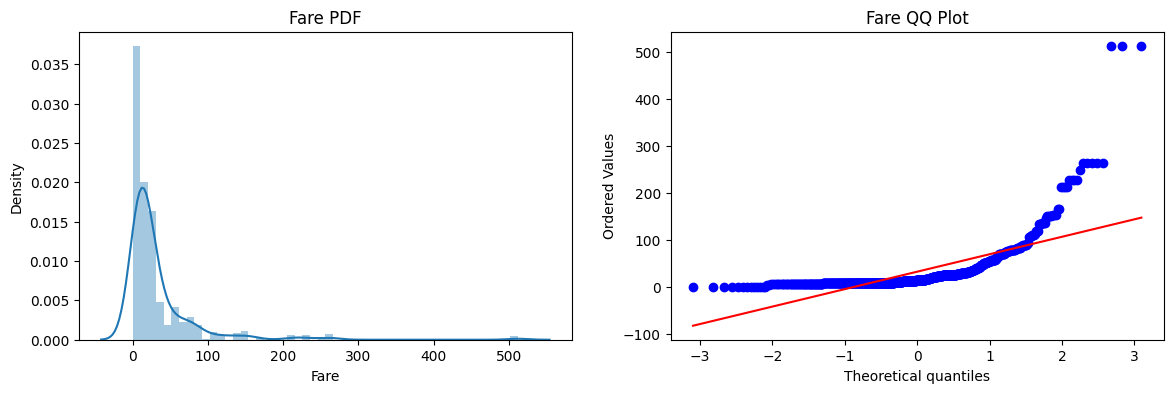

In [12]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [14]:
LR = LogisticRegression()
DT = DecisionTreeClassifier()

In [15]:
LR.fit(X_train,y_train)
DT.fit(X_train,y_train)

y_pred = LR.predict(X_test)
y_pred1 = DT.predict(X_test)

print('LR score', accuracy_score(y_test,y_pred))
print('DT score', accuracy_score(y_test,y_pred1))

LR score 0.6480446927374302
DT score 0.664804469273743


In [19]:
trf = FunctionTransformer(func = np.log1p)

In [20]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [21]:
LR.fit(X_train_transformed,y_train)
DT.fit(X_train_transformed,y_train)

y_pred = LR.predict(X_test_transformed)
y_pred1 = DT.predict(X_test_transformed)

print('LR score', accuracy_score(y_test,y_pred))
print('DT score', accuracy_score(y_test,y_pred1))

LR score 0.6815642458100558
DT score 0.6703910614525139


In [24]:
X_transformed_cross_val = trf.fit_transform(X)

print('LR score', cross_val_score(LR,X_transformed_cross_val,y,cv=10,scoring='accuracy').mean())
print('DT score', cross_val_score(DT,X_transformed_cross_val,y,cv=10,scoring='accuracy').mean())

LR score 0.678027465667915
DT score 0.6543820224719101


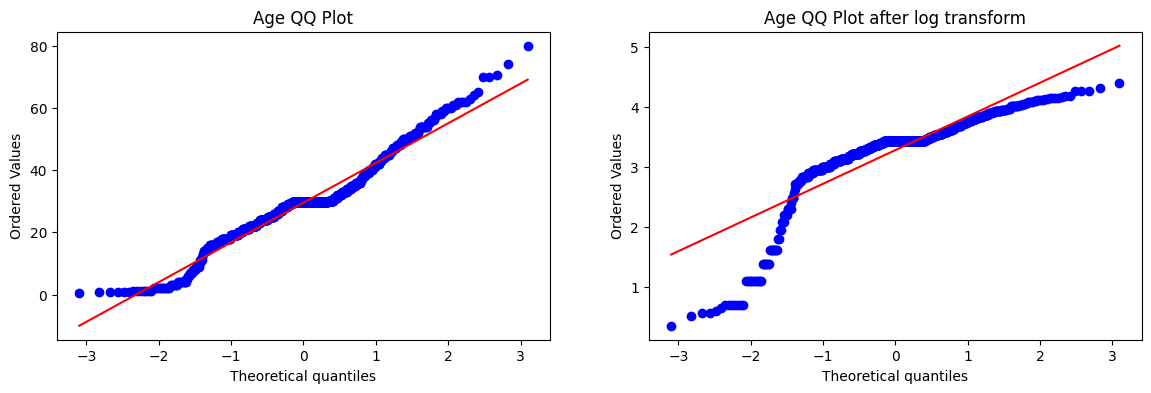

In [32]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,4))

stats.probplot(X_train['Age'], dist="norm", plot=ax1)
ax1.set_title('Age QQ Plot')

stats.probplot(X_train_transformed['Age'], dist="norm", plot=ax2)
ax2.set_title('Age QQ Plot after log transform')

plt.show()

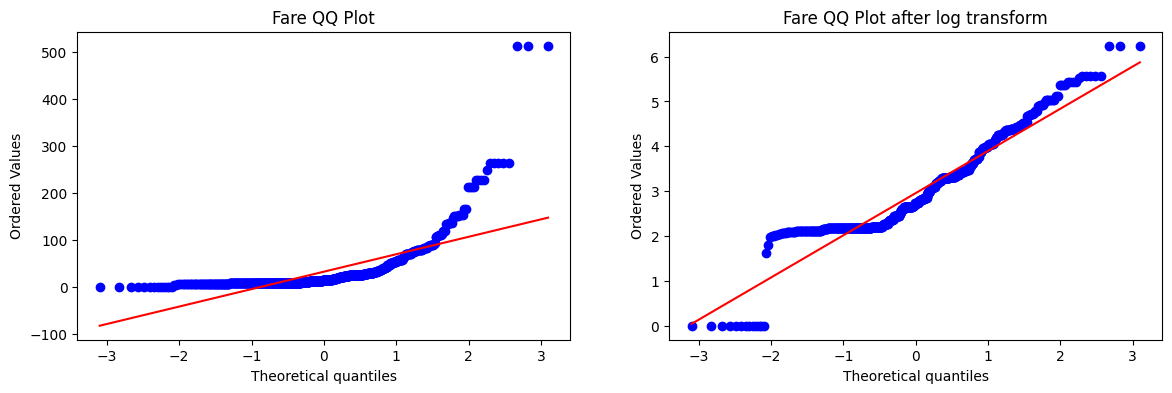

In [33]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,4))

stats.probplot(X_train['Fare'], dist="norm", plot=ax1)
ax1.set_title('Fare QQ Plot')

stats.probplot(X_train_transformed['Fare'], dist="norm", plot=ax2)
ax2.set_title('Fare QQ Plot after log transform')

plt.show()

In [34]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6759776536312849
LR 0.6712609238451936
DT 0.6588264669163546


In [42]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([(transform.__name__,FunctionTransformer(transform),['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(X)

    LR = LogisticRegression()
    DT = DecisionTreeClassifier()

    print("LR Accuracy",np.mean(cross_val_score(LR,X_trans,y,scoring='accuracy',cv=10)))
    print("DT Accuracy",np.mean(cross_val_score(DT,X_trans,y,scoring='accuracy',cv=10)))


    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

LR Accuracy 0.6712609238451936
DT Accuracy 0.6633208489388264


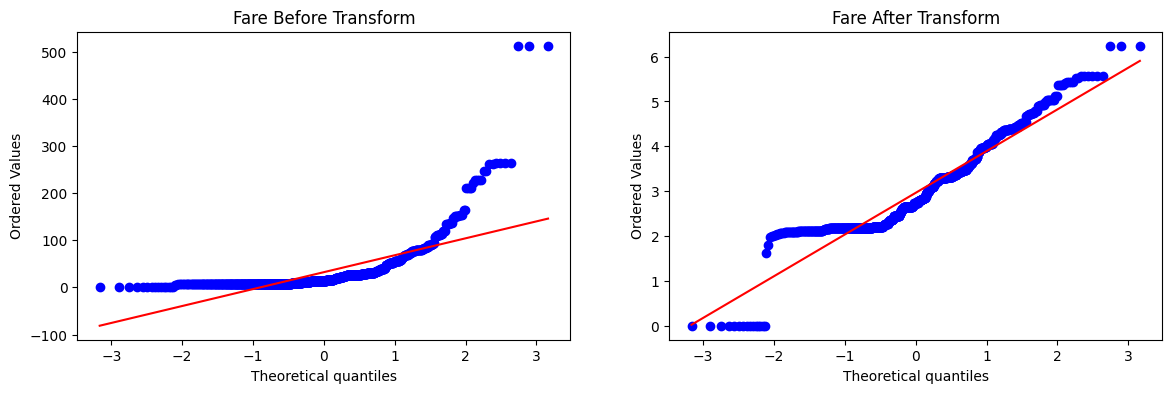

In [43]:
apply_transform(np.log1p)

LR Accuracy 0.6195131086142323
DT Accuracy 0.604943820224719


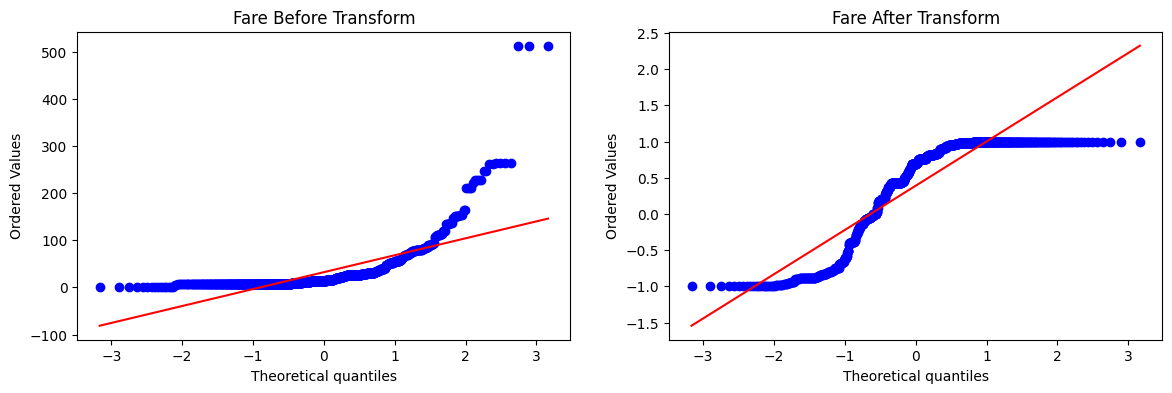

In [44]:
apply_transform(np.sin)

--- Evaluating np.log1p ---
LR Accuracy 0.6712609238451936
DT Accuracy 0.6633083645443196


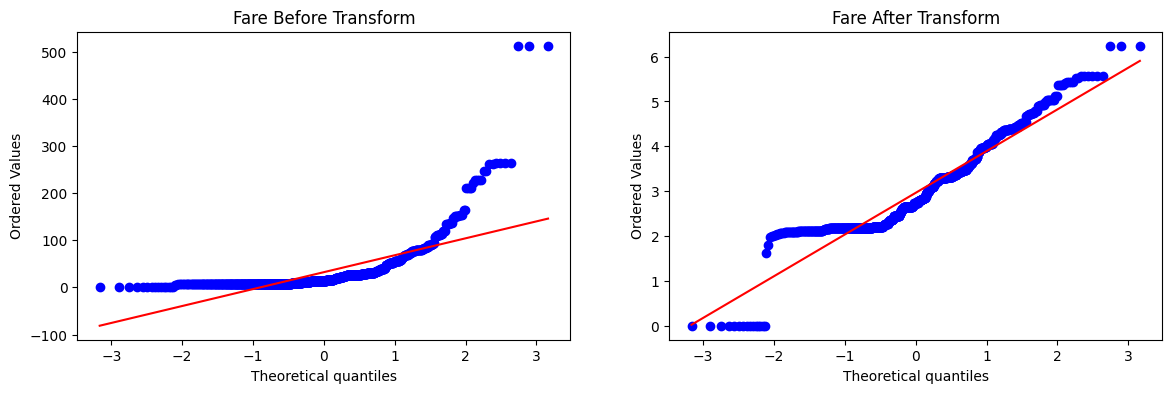


--- Evaluating lambda x: np.log1p(x**2) ---
LR Accuracy 0.6723845193508116
DT Accuracy 0.6644569288389512


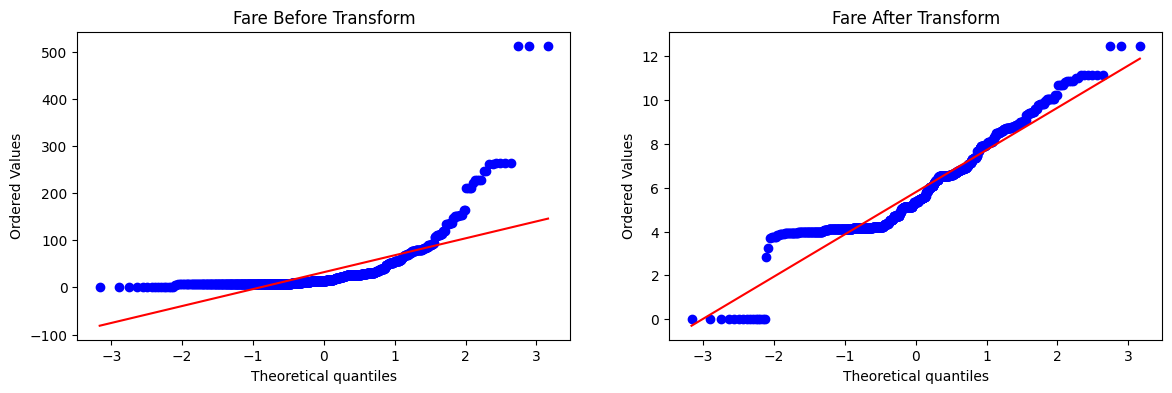


--- Evaluating np.sqrt ---
LR Accuracy 0.6611485642946316
DT Accuracy 0.6588389513108615


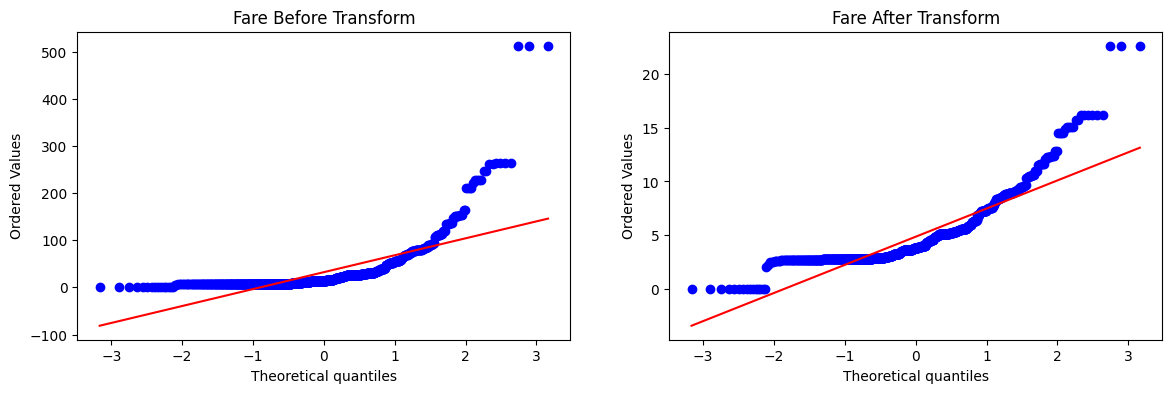


--- Evaluating np.cbrt ---
LR Accuracy 0.6633957553058677
DT Accuracy 0.6588514357053682


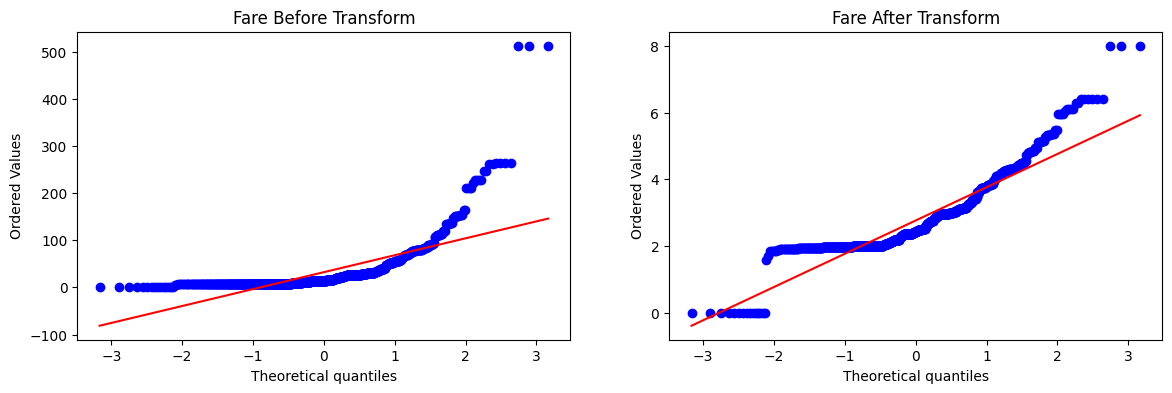


--- Evaluating lambda x: x (No transformation baseline) ---
LR Accuracy 0.6589013732833957
DT Accuracy 0.6588264669163546


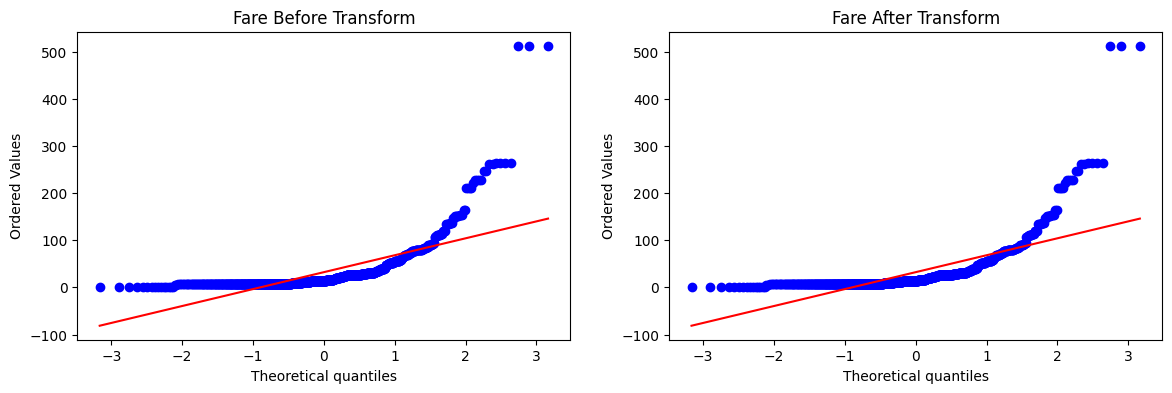

In [45]:
print("--- Evaluating np.log1p ---")
apply_transform(np.log1p)

print("\n--- Evaluating lambda x: np.log1p(x**2) ---")
apply_transform(lambda x: np.log1p(x**2))

print("\n--- Evaluating np.sqrt ---")
apply_transform(np.sqrt)

print("\n--- Evaluating np.cbrt ---")
apply_transform(np.cbrt)

print("\n--- Evaluating lambda x: x (No transformation baseline) ---")
apply_transform(lambda x: x)

Box Cox Transformation

In [57]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import r2_score

In [58]:
df = pd.read_csv('concrete_data.csv')

In [59]:
df.shape

(1030, 9)

In [60]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [61]:
X = df.drop(columns = 'Strength')
y = df.iloc[:,-1]

In [62]:
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
# Applying Regression without any transformation
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)

0.627553179231485

In [64]:
# Cross checking with cross val score
lr = LinearRegression()
np.mean(cross_val_score(lr,X,y,scoring='r2'))

np.float64(0.46099404916628606)

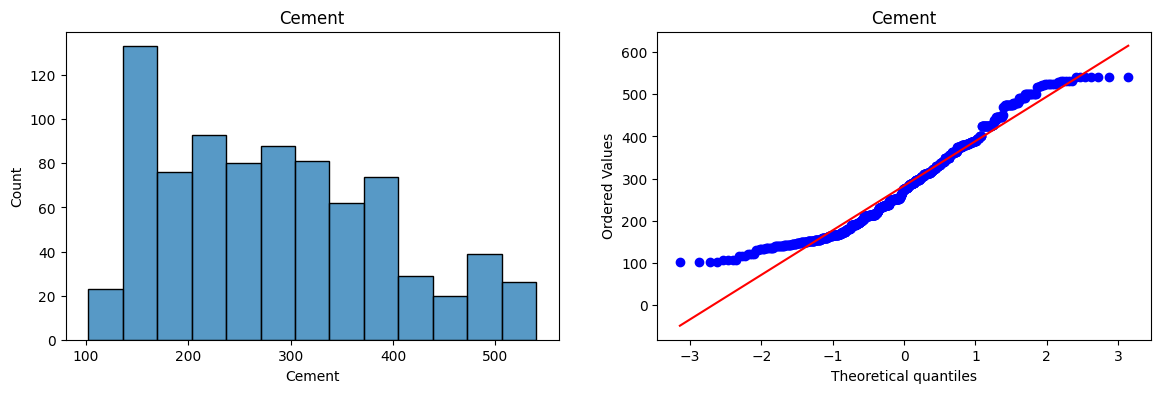

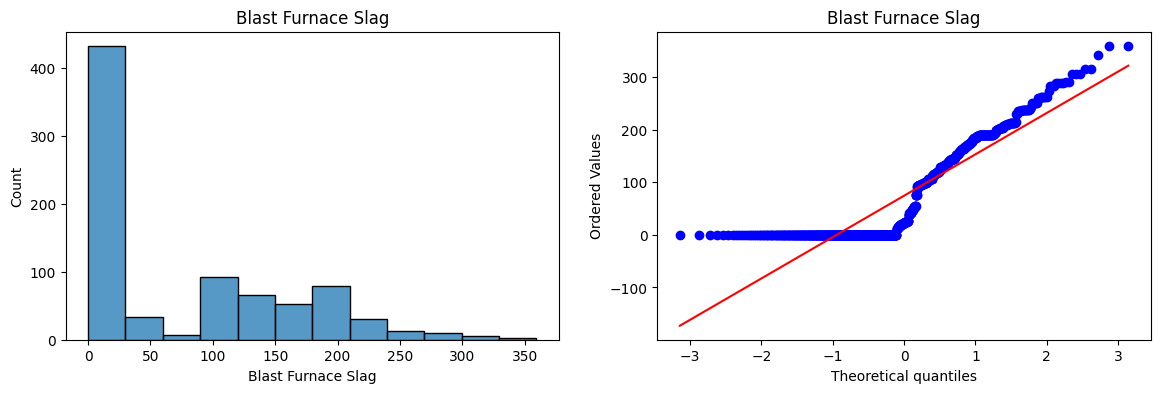

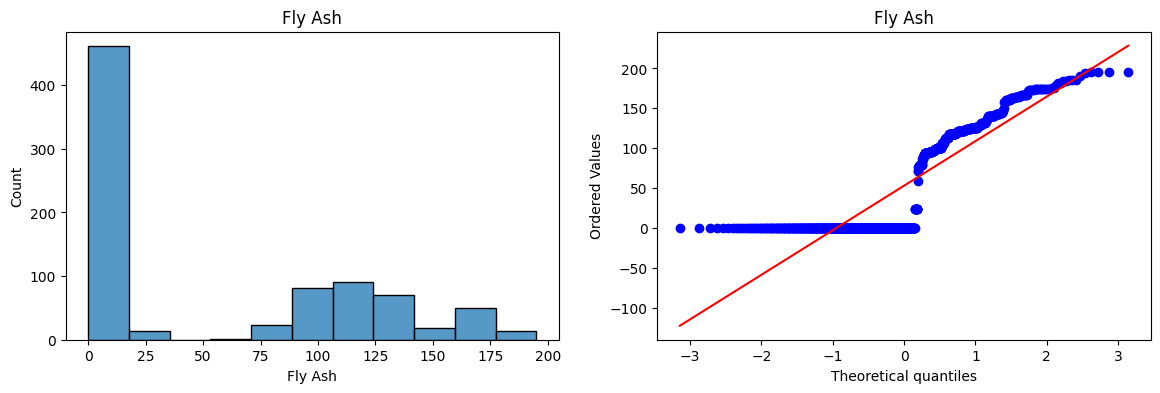

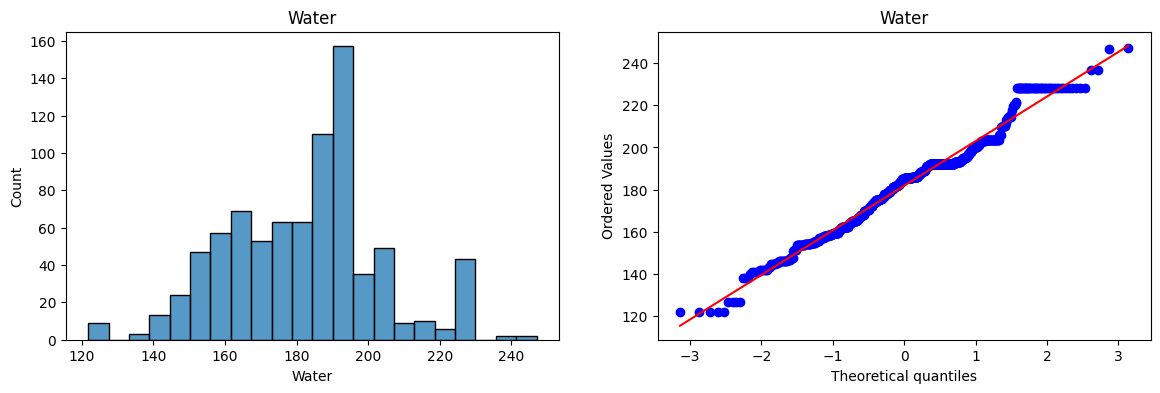

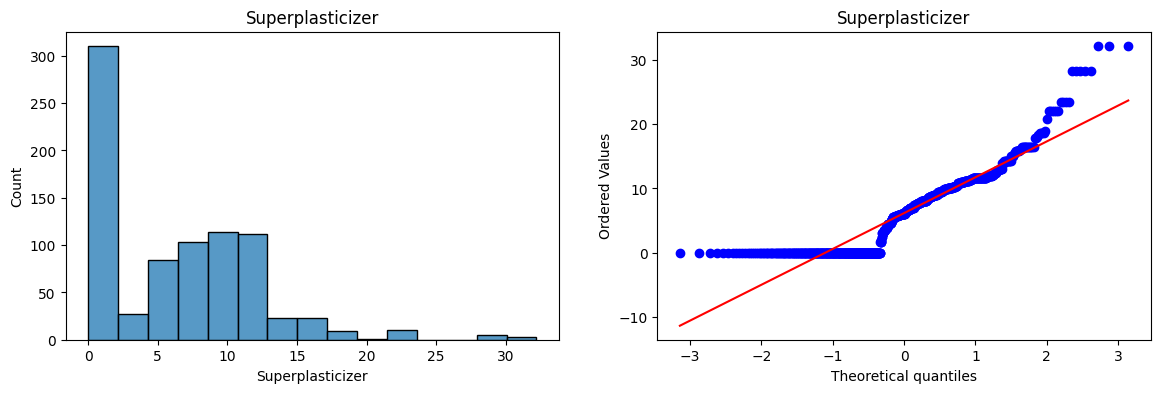

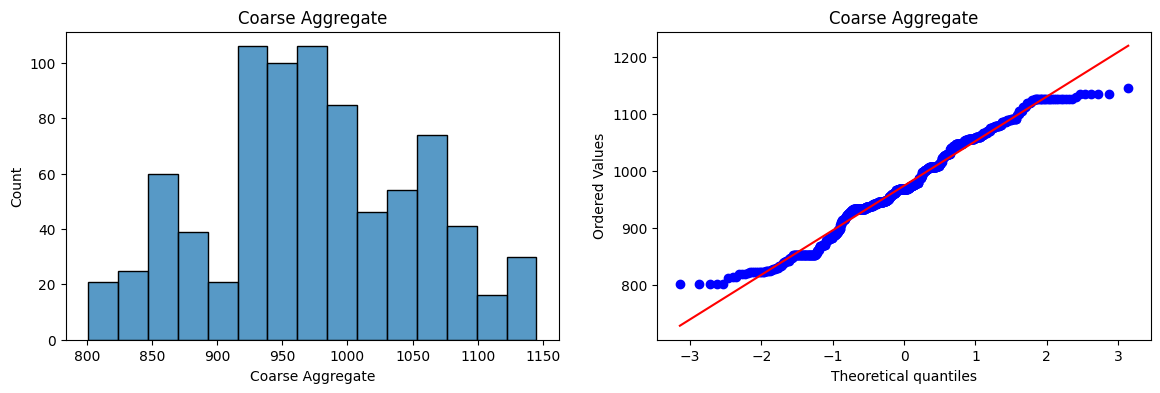

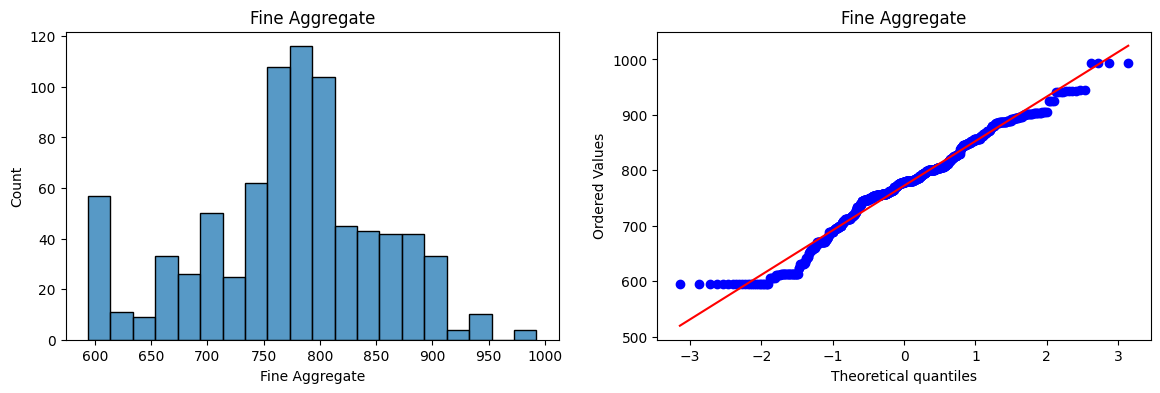

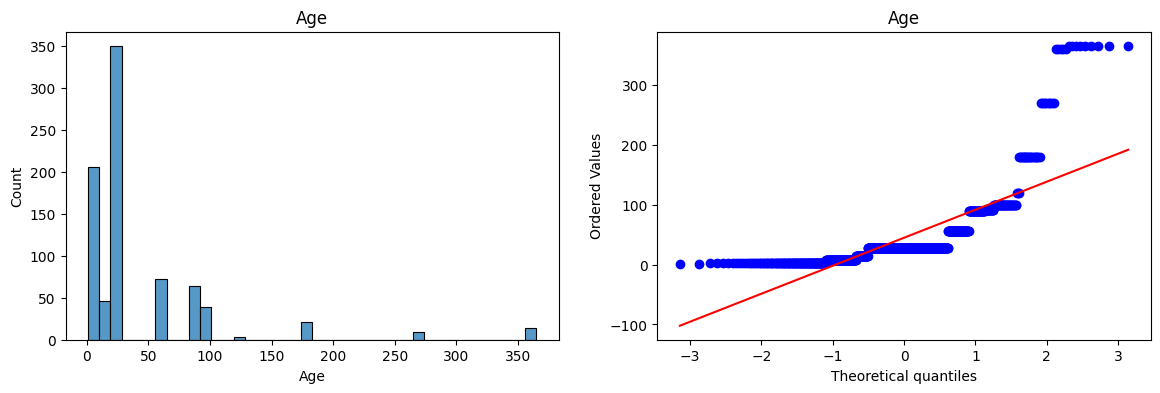

In [68]:
# Plotting the distplots without any transformation

for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [69]:
# Applying Box-Cox Transform

pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [70]:
# Applying linear regression on transformed data

lr = LinearRegression()
lr.fit(X_train_transformed,y_train)

y_pred2 = lr.predict(X_test_transformed)

r2_score(y_test,y_pred2)

0.8047824993083206

In [71]:
# Using cross val score

pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+0.0000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.6658537935432477)

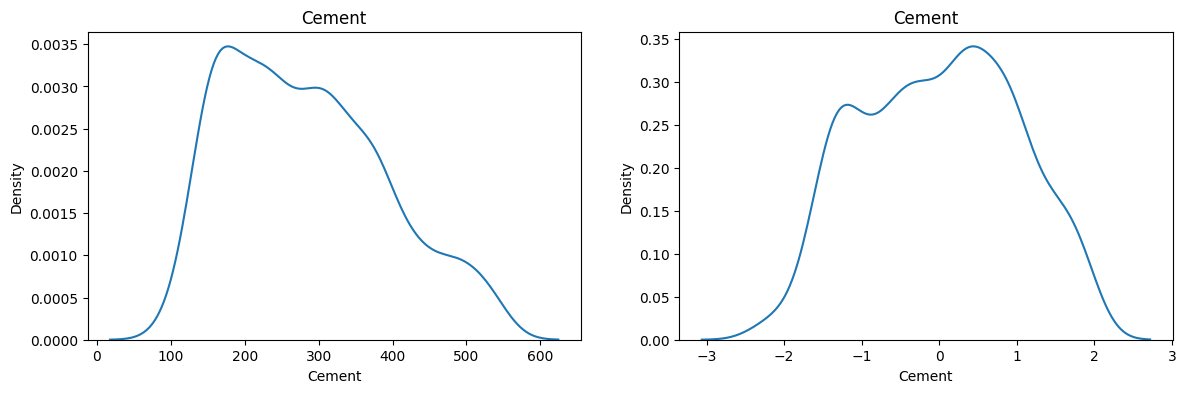

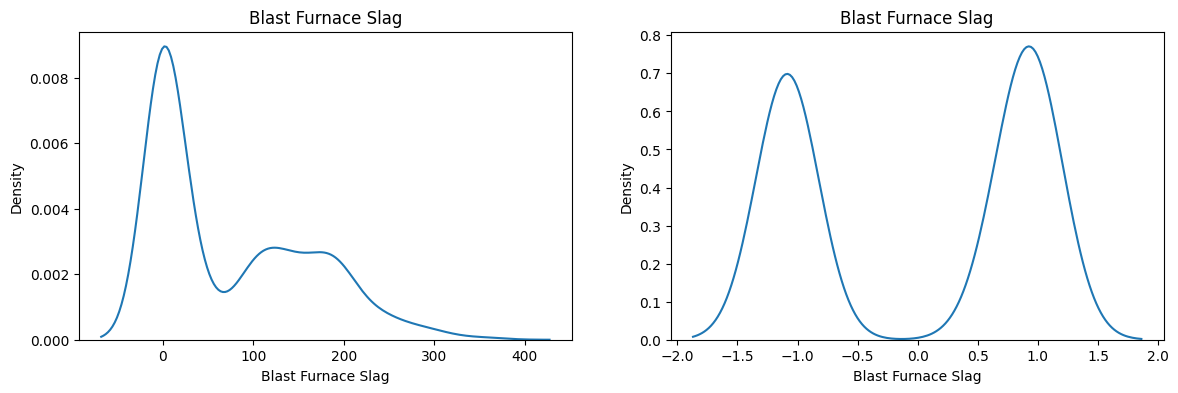

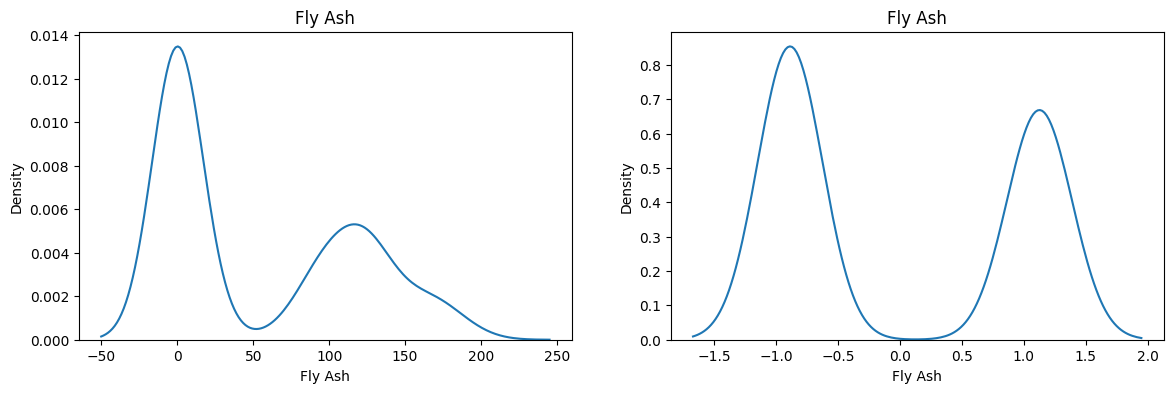

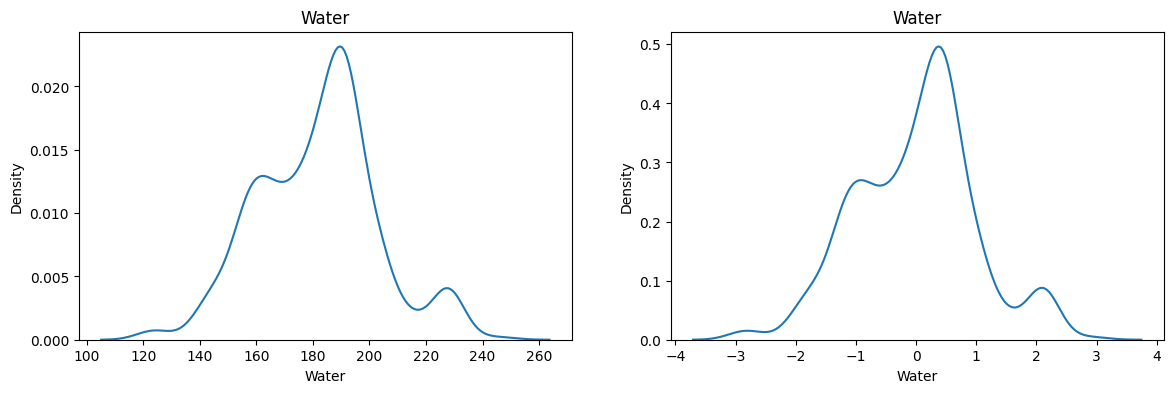

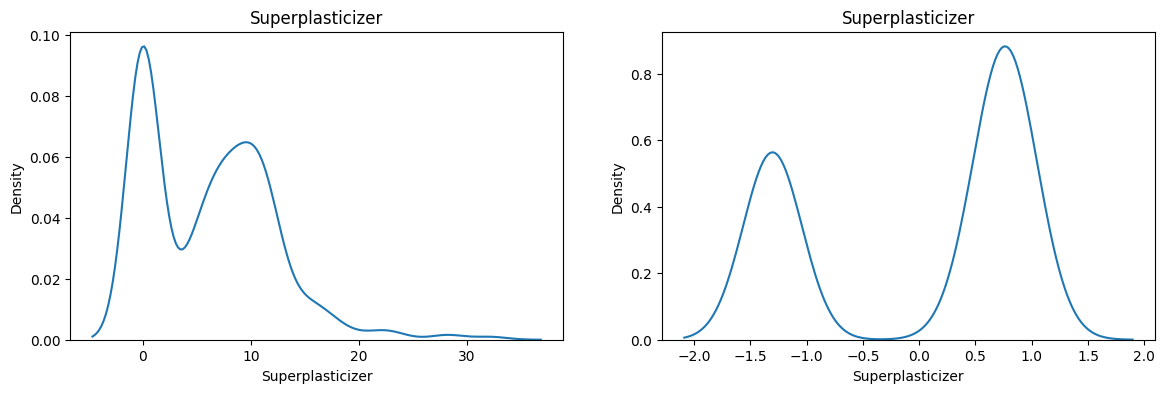

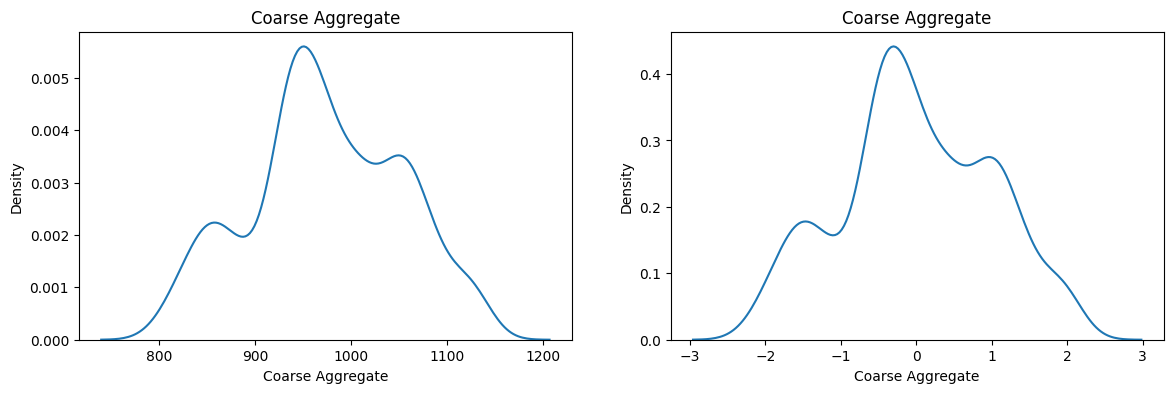

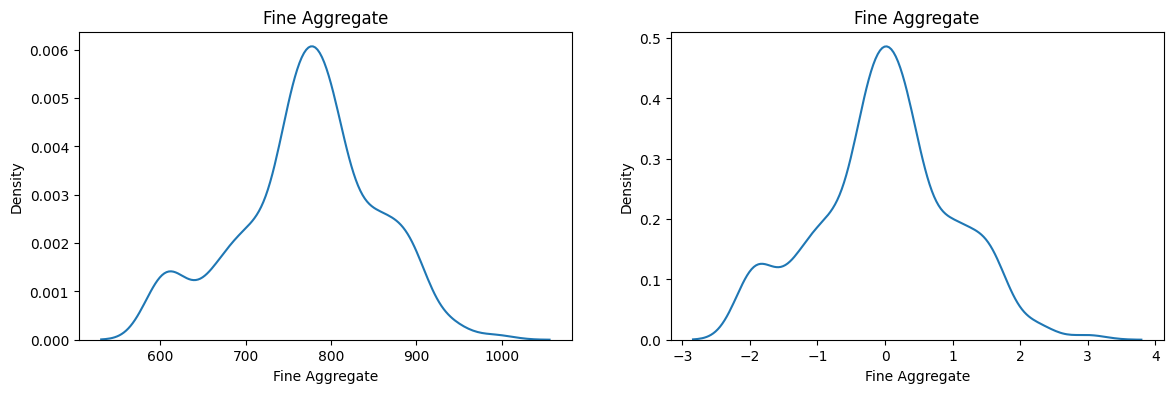

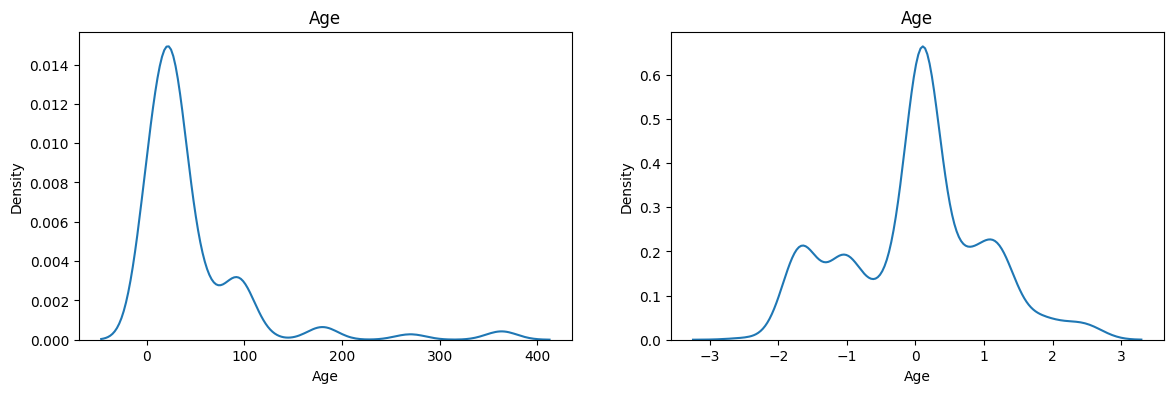

In [78]:
# Before and after comparision for Box-Cox Plot
X_train_transformed = pd.DataFrame(X_train_transformed,columns=X_train.columns)

for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    sns.kdeplot(X_train_transformed[col])
    plt.title(col)

    plt.show()

In [79]:
# Apply Yeo-Johnson transform

pt1 = PowerTransformer() # by default is YeoJohnson

X_train_transformed2 = pt1.fit_transform(X_train)
X_test_transformed2 = pt1.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed2,y_train)

y_pred3 = lr.predict(X_test_transformed2)

print(r2_score(y_test,y_pred3))

pd.DataFrame({'cols':X_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

0.8161906512004999


,cols,Yeo_Johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [80]:
# applying cross val score

pt = PowerTransformer()
X_transformed2 = pt.fit_transform(X)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed2,y,scoring='r2'))

np.float64(0.6834625141500866)

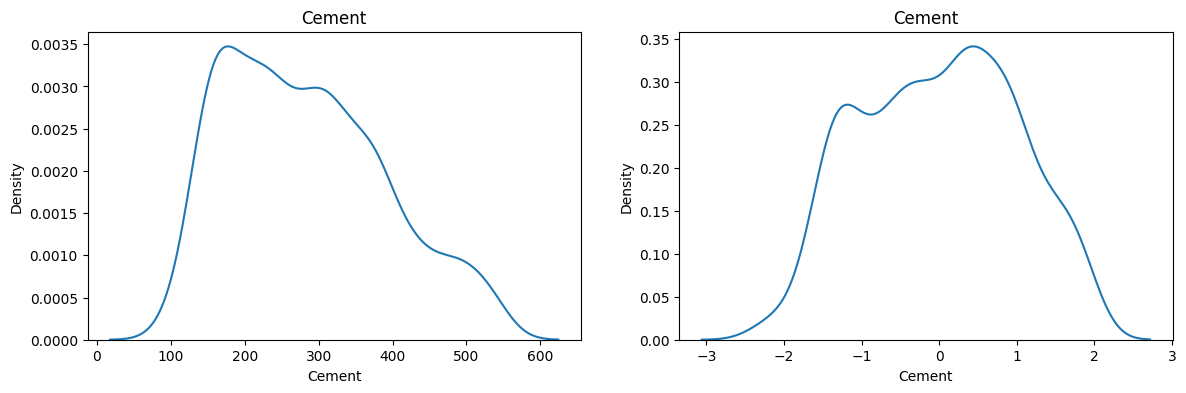

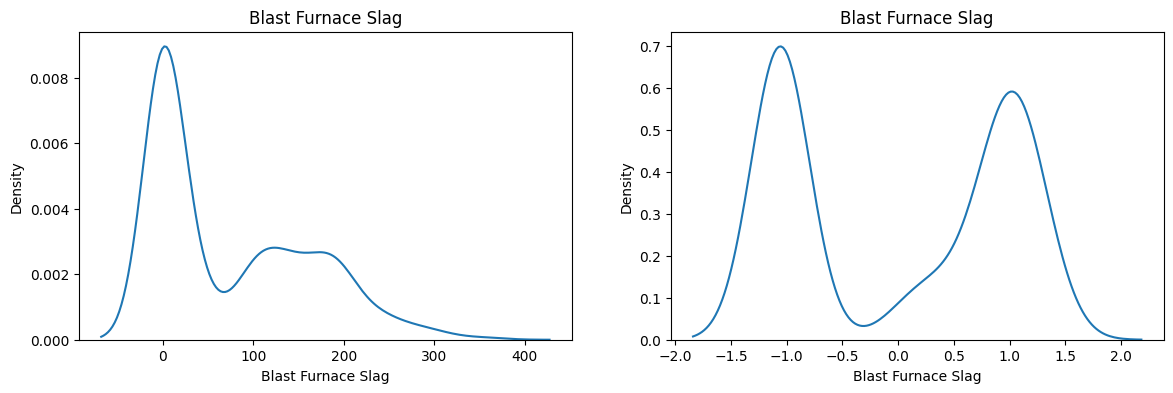

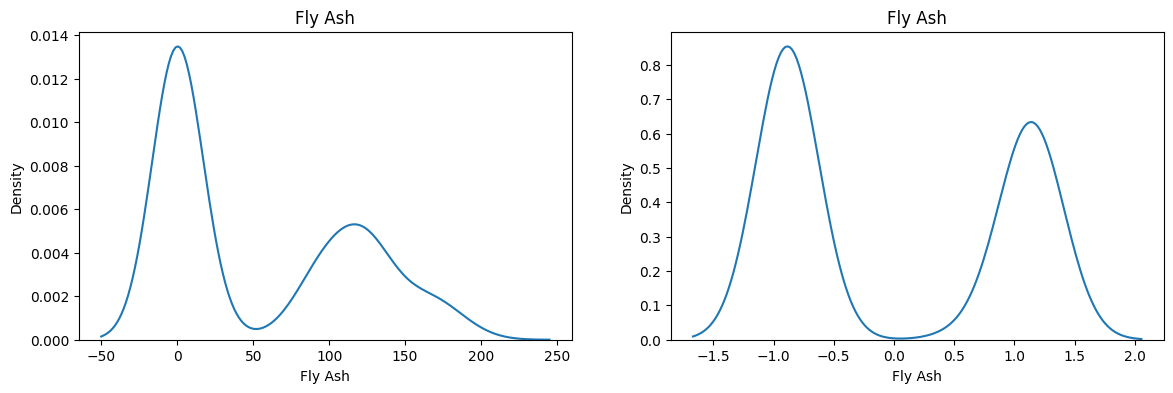

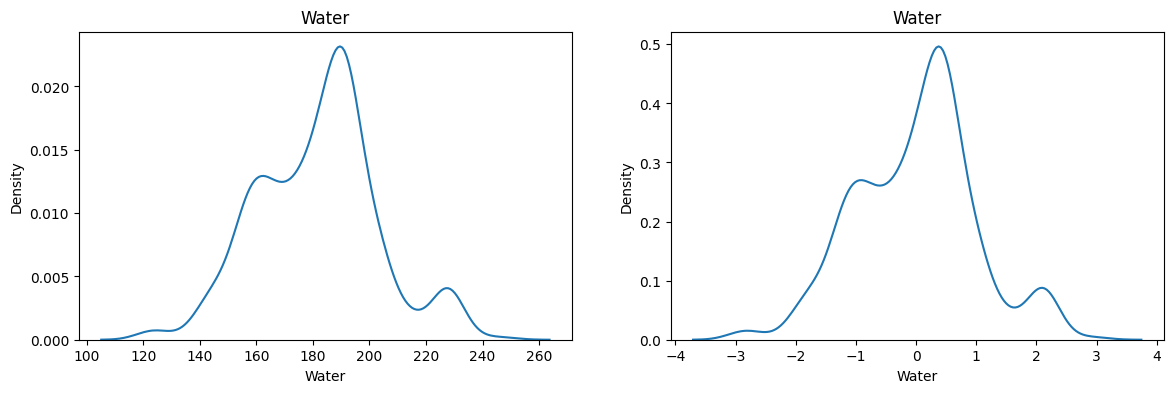

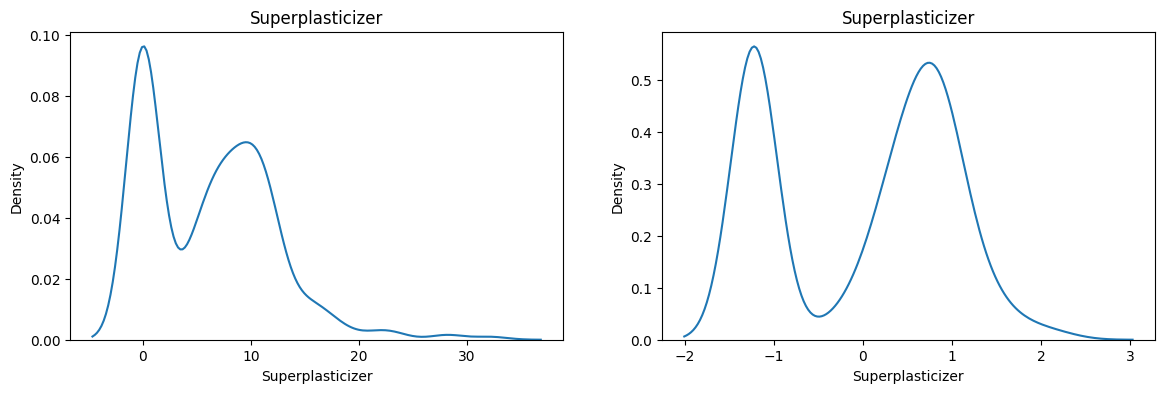

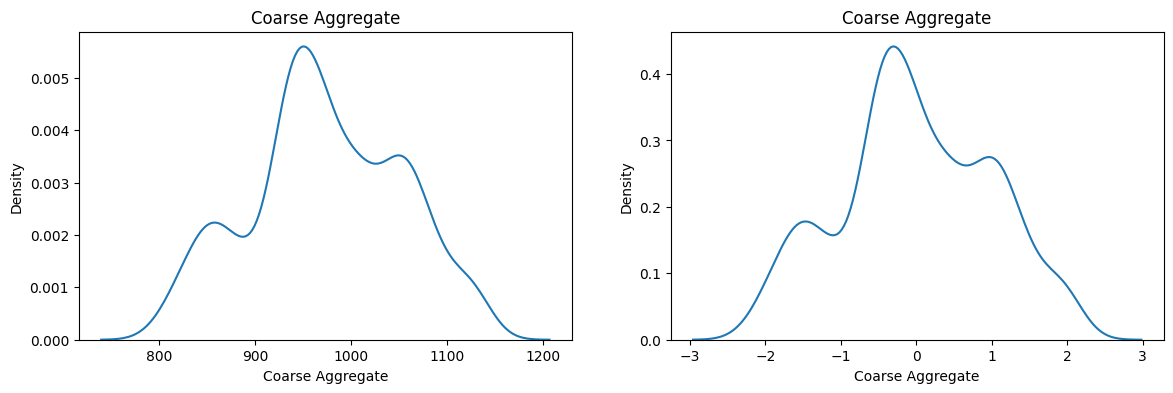

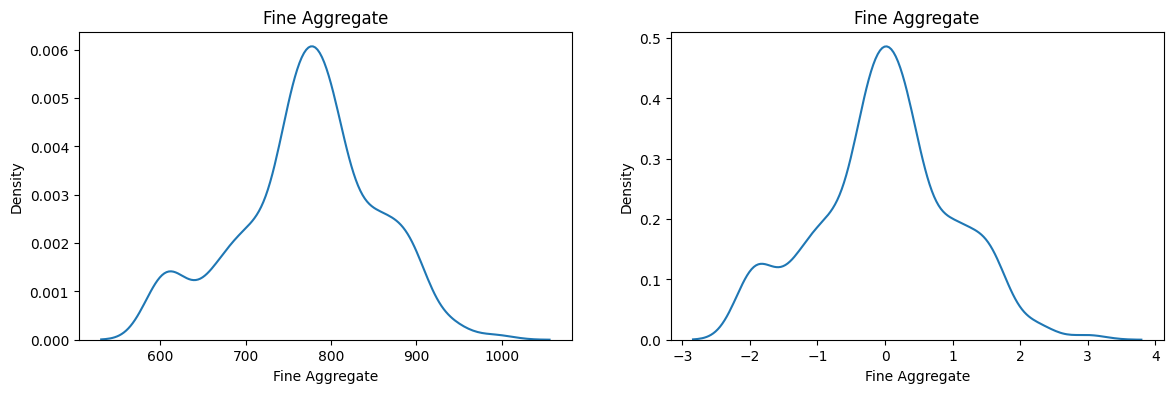

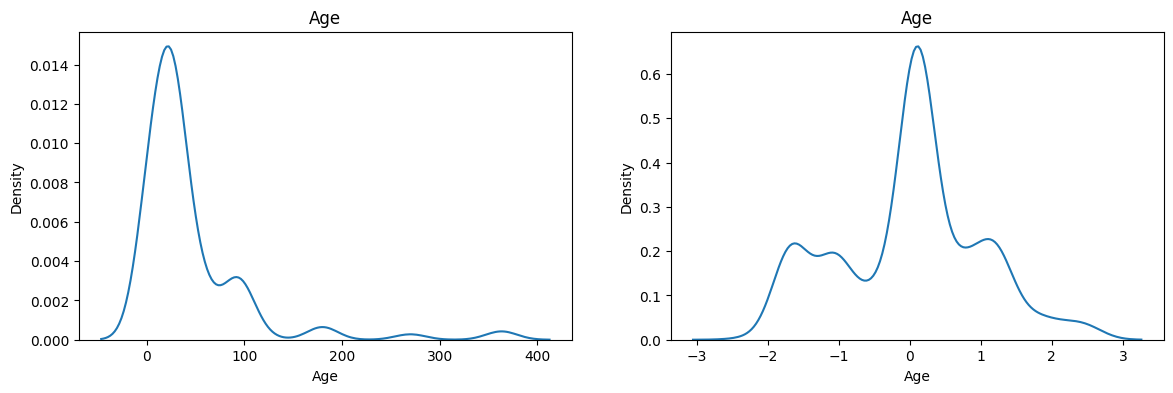

In [81]:
X_train_transformed2 = pd.DataFrame(X_train_transformed2,columns=X_train.columns)
# Before and after comparision for Yeo-Johnson

for col in X_train_transformed2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    sns.kdeplot(X_train_transformed2[col])
    plt.title(col)

    plt.show()

In [76]:
# Side by side Lambdas
pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_,'Yeo_Johnson_lambdas':pt1.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,Cement,0.169544,0.174348
1,Blast Furnace Slag,0.016633,0.015715
2,Fly Ash,-0.136480,-0.161447
3,Water,0.808438,0.771307
4,Superplasticizer,0.264160,0.253935
5,Coarse Aggregate,1.129395,1.130050
6,Fine Aggregate,1.830763,1.783100
7,Age,0.001771,0.019885


Binning and Binarization

Discretization is the process of transforming contnuous variables into discrete variables by creating a set of contiguos intervals that span the range of the variable's values. Discretization is also called binning

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])

In [5]:
df.dropna(inplace=True)

In [6]:
df.shape

(714, 3)

In [7]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.6223776223776224

In [10]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6261345852895148)

In [11]:

kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [12]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [13]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [14]:
trf.named_transformers_['first'].n_bins_

array([15])

In [15]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [16]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [17]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [18]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
179,36.0,10.0,0.00,0.0,"(35.0, 38.0]",NaN
297,2.0,0.0,151.55,14.0,"(0.42, 6.0]","(108.9, 512.329]"
302,19.0,3.0,0.00,0.0,"(16.0, 19.0]",NaN
160,44.0,12.0,16.10,7.0,"(42.0, 47.0]","(14.454, 18.75]"
132,47.0,13.0,14.50,7.0,"(42.0, 47.0]","(14.454, 18.75]"


In [19]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [20]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [21]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6303012519561815)

In [22]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

0.6303208137715179


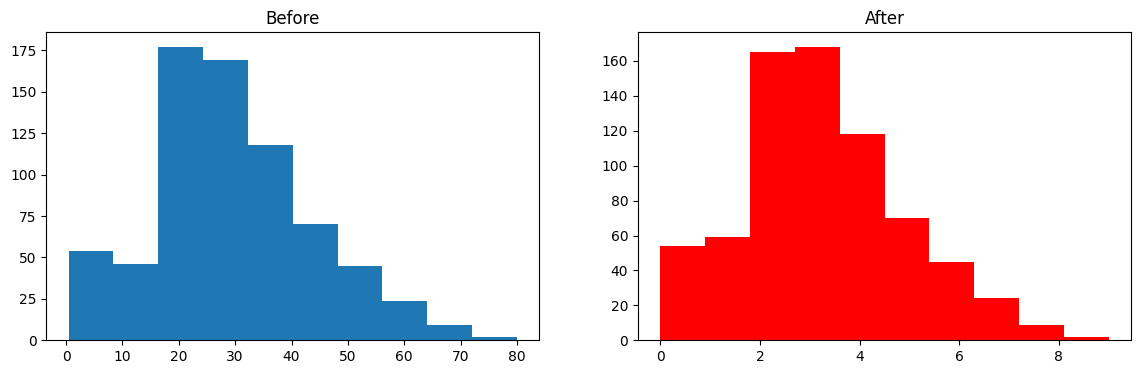

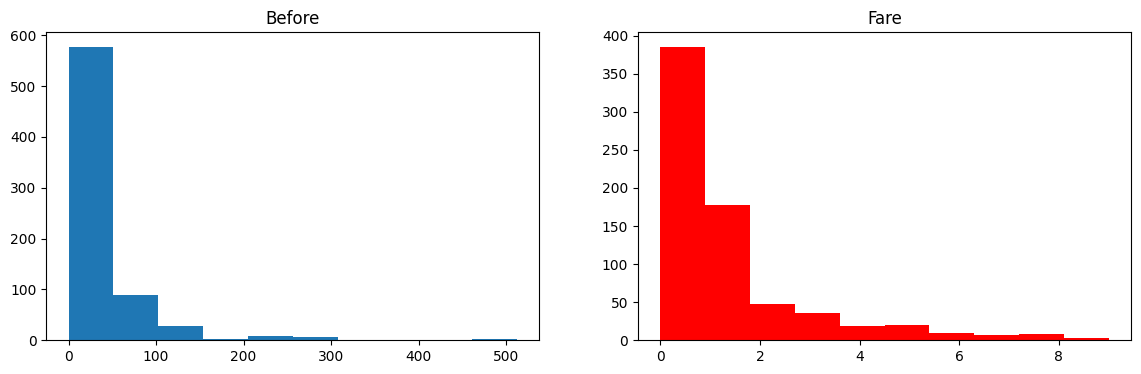

In [23]:
discretize(10,'kmeans')

In [24]:
df = pd.read_csv('titanic.csv')

In [25]:
df['family'] = df['SibSp'] + df['Parch']

In [26]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin','SibSp','Parch'],inplace=True)

In [27]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,family
0,0,3,male,22.0,7.2500,S,1
1,1,1,female,38.0,71.2833,C,1
2,1,3,female,26.0,7.9250,S,0
3,1,1,female,35.0,53.1000,S,1
4,0,3,male,35.0,8.0500,S,0


In [28]:
X= df.drop(columns=['Survived'])
y = df['Survived']

In [29]:
X= df.drop(columns=['Survived'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
X_train.loc[:, 'Age'] = X_train['Age'].fillna(X_train['Age'].mean())
X_test.loc[:, 'Age'] = X_test['Age'].fillna(X_test['Age'].mean())
X_train.loc[:, 'Embarked'] = X_train['Embarked'].fillna(X_train['Embarked'].mode()[0])
X_test.loc[:, 'Embarked'] = X_test['Embarked'].fillna(X_test['Embarked'].mode()[0])

In [31]:
X_train = pd.get_dummies(X_train, columns=['Sex', 'Embarked'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Sex', 'Embarked'], drop_first=True)

Now that the categorical features are one-hot encoded, we can train the `DecisionTreeClassifier`.

In [32]:
#Without binarisation

clf = DecisionTreeClassifier()

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test,y_pred)

0.7486033519553073

In [33]:
from sklearn.preprocessing import Binarizer
trf = ColumnTransformer([
    ('first',Binarizer(copy=False),['family'])
], remainder='passthrough')

X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [34]:
X_train_trf

array([[0, 1, 45.5, ..., True, False, True],
       [0, 2, 23.0, ..., True, False, True],
       [0, 3, 32.0, ..., True, False, True],
       ...,
       [1, 3, 41.0, ..., True, False, True],
       [1, 1, 14.0, ..., False, False, True],
       [1, 1, 21.0, ..., True, False, True]], dtype=object)

In [35]:
clf = DecisionTreeClassifier()

clf.fit(X_train_trf,y_train)

y_pred = clf.predict(X_test_trf)

accuracy_score(y_test,y_pred)

0.7430167597765364